In [234]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import random
import math
import copy
from Stock import Coin,User


In [235]:
torch.backends.cudnn.enabled = False
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [236]:
class NanoModel(nn.Module):
    def __init__(self,input_size,hidden_size,output_size):
        super(NanoModel, self).__init__()
        self.lstm = nn.LSTM(input_size=input_size,hidden_size=hidden_size,num_layers=2,batch_first=True,dropout=0.2)

        self.classifier = nn.Sequential(
            nn.Linear(hidden_size,hidden_size//2),
            nn.Sigmoid(),
            nn.Linear(hidden_size//2,output_size),
            nn.Dropout(0.2)
        )
        self.target = nn.Linear(hidden_size,1)
        self.relu = nn.ReLU()

    def forward(self,x):
        x = x.unsqueeze(-1)
        out, (h_n, c_n) = self.lstm(x)
        out = h_n[-1]
        out = self.relu(out)

        target = self.target(out)
        chances = self.classifier(out)
        return chances, target

In [237]:
import matplotlib.pyplot as plt
import random
from Stock import Coin, User

class TradeNetLSTM(nn.Module):
    def __init__(self, input_size,num_layers, hidden_size, output_size):
        super(TradeNetLSTM, self).__init__()


        self.lstm = nn.LSTM(input_size=input_size,
                                    hidden_size=hidden_size,
                                    num_layers=num_layers,
                                    batch_first=True,
                                    dropout=0.2)
        self.fc = nn.Linear(hidden_size,hidden_size)

        self.fc1 = nn.Linear(hidden_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, output_size)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = x.unsqueeze(-1)

        _, (h_n, _) = self.lstm(x)

        out = h_n[-1]

        out = self.fc1(out)
        out = self.relu(out)
        out = self.fc2(out)

        first_part = out[:, :1]
        other_part = out[:, 1:]

        first_activated = torch.relu(first_part)
        other_activated = torch.sigmoid(other_part)

        return torch.cat((first_activated, other_activated), dim=1)

#--------------------------------------------------------
#функция обвала рынка
def crash(coin_list, percentage):
    for coin in coin_list:
        before = coin.currency
        coin.currency *= (1 - percentage / 100)
        # print(f'{coin.name} before:{before} after:{coin.currency}')


#демонстрация
# d_coin_list = [Coin(f'd_coin{i}',random.randint(10,100),random.randint(10,100)) for i in range(3)]
# crash(d_coin_list,40)

#--------------------------------------------------------
#функция бума на рынке
def stock_boom(coin_list, percentage):
    for coin in coin_list:
        before = coin.currency
        coin.currency *= (1 + percentage / 100)
        # print(f'{coin.name} before:{before} after:{coin.currency}')


#демонстрация
# d_coin_list = [Coin(f'd_coin{i}',random.randint(10,100),random.randint(10,100)) for i in range(3)]
# stock_boom(d_coin_list,10)

#--------------------------------------------------------

def main(steps,users_count,coins_count,each_ai_users_count):
    percent_to_stock = 0.5
    target_liquidity_per_user = 1000

    world_coin = Coin('world_coin', 10 ** 9, 10 ** 9)
    world_manager = [0, [world_coin]]

    users_list = []
    ai_users = []

    events = ['crash', 'boom', 'nothing']
    events_weight = [5, 5, 90]

    for i in range(users_count):
        u = User(f'user{i}', 1000, world_coin, world_manager[1])
        u.initialize_nick()
        u.register_in_wc()
        users_list.append(u)

    models_list = ['stocker11.pth', 'stocker_l.pth', 'stocker2.pth']
    loaded_models = {}
    for m_path in models_list:
        m = NanoModel(1, 32, 3)
        try:
            m.load_state_dict(torch.load(m_path, weights_only=True))
        except:
            pass
        m.eval()
        loaded_models[m_path] = m

    for i in range(each_ai_users_count):
        for m_path in models_list:
            nick = f"{m_path.split('.')[0]}_{i}"
            neuro_user = User(nick, random.randint(500, 2000), world_coin, world_manager[1])
            neuro_user.initialize_nick()
            neuro_user.register_in_wc()
            neuro_user.model = copy.deepcopy(loaded_models[m_path])
            users_list.append(neuro_user)
            ai_users.append(neuro_user)

    for i in range(coins_count):
        world_manager[1].append(Coin(f'Coin{i}', random.randint(5000, 50000), random.randint(1000, 10000)))

    history = {
        'prices': {coin.name: [] for coin in world_manager[1]},
        'wealth': {user.nickname: [] for user in users_list}
    }

    for step in range(steps):
        event = random.choices(events, weights=events_weight, k=1)[0]
        if event == 'crash':
            crash(world_manager[1][1:], random.randint(10, 25))
        elif event == 'boom':
            stock_boom(world_manager[1][1:], random.randint(5, 30))

        for user in users_list:
            target_coin = random.choice(world_manager[1][1:])
            coin_hist = history['prices'][target_coin.name]

            if len(coin_hist) >= 32:
                window = coin_hist[-32:]
                norm_window = [p / (window[0] + 1e-8) for p in window]

                if user in ai_users:
                    input_data = torch.tensor([norm_window], dtype=torch.float32)
                    with torch.no_grad():
                        chances, target_val = user.model(input_data)
                        chances = chances[0].tolist()
                        target_val = target_val.item()

                    if chances[1] > chances[0]:
                        buy_amount = user.wc_count * 0.2 * min(target_val, random.uniform(0.1, 1.0))
                        user.buy(buy_amount, target_coin)
                    else:
                        user.sell(target_val, target_coin)
                else:
                    r = calc_single_y(norm_window)
                    if r[2] * random.uniform(1, 2) > r[1]:
                        user.buy(r[0], target_coin)
                    else:
                        user.sell(r[0], target_coin)

            world_manager[0] += user.apply_request(percent_to_stock)

        current_wc_supply = sum(u.wc_count for u in users_list) + world_manager[0]
        target_wc_supply = len(users_list) * target_liquidity_per_user

        if current_wc_supply < target_wc_supply:
            shortage = (target_wc_supply - current_wc_supply) / len(users_list)
            for u in users_list:
                u.receive_yield(shortage)
            world_manager[0] = max(0, world_manager[0] - (target_wc_supply - current_wc_supply))

        world_coin.currency = 1.0
        world_coin.on_market = sum(u.wc_count for u in users_list)
        world_coin.capitalization = world_coin.on_market

        for coin in world_manager[1]:
            history['prices'][coin.name].append(coin.currency)
        for user in users_list:
            current_wealth = user.wc_count + sum(user.wallet.get(c.name, 0) * c.currency for c in world_manager[1][1:])
            history['wealth'][user.nickname].append(current_wealth)

    return history
#--------------------------------------------------------
# Построение графиков
def graphics(history):
    plt.style.use('ggplot')
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

    # График цен
    for coin_name, prices in history['prices'].items():
        ax1.plot(prices, label=coin_name)
    ax1.set_title('Динамика курсов монет')
    ax1.set_ylabel('Цена в WC')
    ax1.legend()

    # График капитала
    for user_nick, wealth_history in history['wealth'].items():
        ax2.plot(wealth_history, label=user_nick)
    ax2.set_title('Капитализация пользователей (Net Worth)')
    ax2.set_ylabel('Общая стоимость активов')
    ax2.set_xlabel('Шаги симуляции')
    ax2.legend()

    plt.tight_layout()
    plt.show()
#--------------------------------------------------------




In [238]:
model = NanoModel(1,32,3)
optimizer = optim.Adam(model.parameters(),lr=1e-4)
criterion = nn.MSELoss()


In [239]:
total_params = sum(p.numel() for p in model.parameters())
print(total_params)

13540


In [240]:
model.eval()
output = model(torch.tensor([[i +random.randint(-10,10) for i in range(128)]],dtype=torch.float32))
print(output)

(tensor([[ 0.1320,  0.3200, -0.0741]], grad_fn=<AddmmBackward0>), tensor([[0.0661]], grad_fn=<AddmmBackward0>))


Nickname has been initialized as @user0
User: @user0 registered in system
Nickname has been initialized as @user1
User: @user1 registered in system
Nickname has been initialized as @user2
User: @user2 registered in system
Nickname has been initialized as @user3
User: @user3 registered in system
Nickname has been initialized as @stocker11_0
User: @stocker11_0 registered in system
Nickname has been initialized as @stocker_l_0
User: @stocker_l_0 registered in system
Nickname has been initialized as @stocker2_0
User: @stocker2_0 registered in system
Nickname has been initialized as @stocker11_1
User: @stocker11_1 registered in system
Nickname has been initialized as @stocker_l_1
User: @stocker_l_1 registered in system
Nickname has been initialized as @stocker2_1
User: @stocker2_1 registered in system


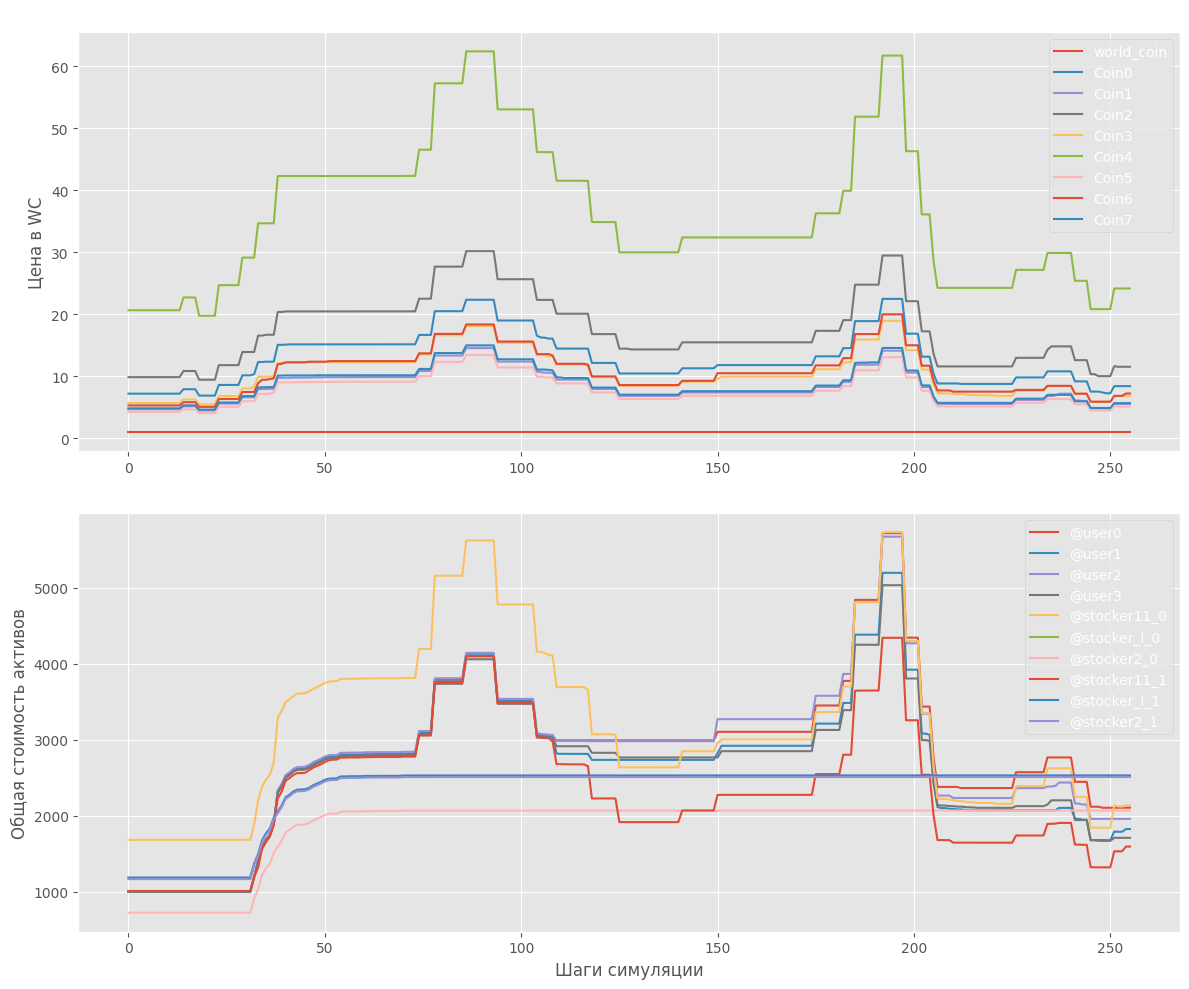

In [241]:
def generate_set(steps=128, window_size=32, u_count=4, c_count=4,ai_users = 4):
    history = main(steps, u_count,c_count,ai_users)
    graphics(history)
    all_windows = []
    all_targets = []

    for coin_name, prices in history['prices'].items():
        if coin_name == 'world_coin': continue

        for i in range(len(prices) - window_size):
            window = prices[i : i + window_size]

            norm_window = [p / (window[0] + 1e-8) for p in window]

            all_windows.append(calc_single_y(window))
            all_targets.append(norm_window)

    return torch.tensor(all_windows, dtype=torch.float32), torch.tensor(all_targets, dtype=torch.float32)

def calc_single_y(price_block):
    k = (max(price_block) - min(price_block)) / len(price_block)
    if k == 0: k = 1 # Защита от деления на 0


    y_last = price_block[-1]
    x = 1 / (y_last * k) if y_last != 0 else 0

    # Нормализация
    v_min, v_max = min(price_block), max(price_block)
    n = (y_last - v_min) / (v_max - v_min) if v_max != v_min else 0.5

    return [x, 1-n,n, 0.5]

Y_train, X_train = generate_set(steps=256, window_size=16,ai_users=2,c_count=8,u_count=4)


In [242]:
print(X_train)
print(Y_train)

X_train = X_train.to(device)
Y_train = Y_train.to(device)

tensor([[1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.1000, 1.1000],
        [1.0000, 1.0000, 1.0000,  ..., 1.1000, 1.1000, 1.1000],
        [1.0000, 1.0000, 1.0000,  ..., 1.1000, 1.1000, 1.1000],
        ...,
        [1.0000, 1.0000, 1.0000,  ..., 0.6970, 0.8085, 0.8085],
        [1.0000, 1.0000, 1.0000,  ..., 0.8085, 0.8085, 0.8085],
        [1.0000, 1.0000, 0.8500,  ..., 0.8085, 0.8085, 0.8085]])
tensor([[2.8235, 0.0000, 1.0000, 0.5000],
        [2.8235, 0.0000, 1.0000, 0.5000],
        [2.8235, 0.0000, 1.0000, 0.5000],
        ...,
        [1.3365, 0.6319, 0.3681, 0.5000],
        [1.3365, 0.6319, 0.3681, 0.5000],
        [1.3365, 0.6319, 0.3681, 0.5000]])


Epoch [1/100] | Loss: 2615555280830603938758656.000000 (Reg: 19549.5742, Clf: 0.2865)
Epoch [2/100] | Loss: 2615555254444222710808576.000000 (Reg: 6645498351550600918859776.0000, Clf: 0.2622)
Epoch [3/100] | Loss: 2615555261813780463484928.000000 (Reg: 21858448637555050264133632.0000, Clf: 0.2497)
Epoch [4/100] | Loss: 2615555256054208918454272.000000 (Reg: 1610.2319, Clf: 0.2287)
Epoch [5/100] | Loss: 2615555266643953297915904.000000 (Reg: 23.5250, Clf: 0.2144)
Epoch [6/100] | Loss: 2615555321863092618395648.000000 (Reg: 678293336831357664362496.0000, Clf: 0.2043)
Epoch [7/100] | Loss: 2615555263097807644393472.000000 (Reg: 133971394445705216.0000, Clf: 0.2068)
Epoch [8/100] | Loss: 2615555319637533981147136.000000 (Reg: 1.4215, Clf: 0.2048)
Epoch [9/100] | Loss: 2615555251425979003830272.000000 (Reg: 2048390160857838139736064.0000, Clf: 0.2602)
Epoch [10/100] | Loss: 2615555255776278363504640.000000 (Reg: 212.7718, Clf: 0.1886)
Epoch [11/100] | Loss: 2615555265103402752802816.000000 

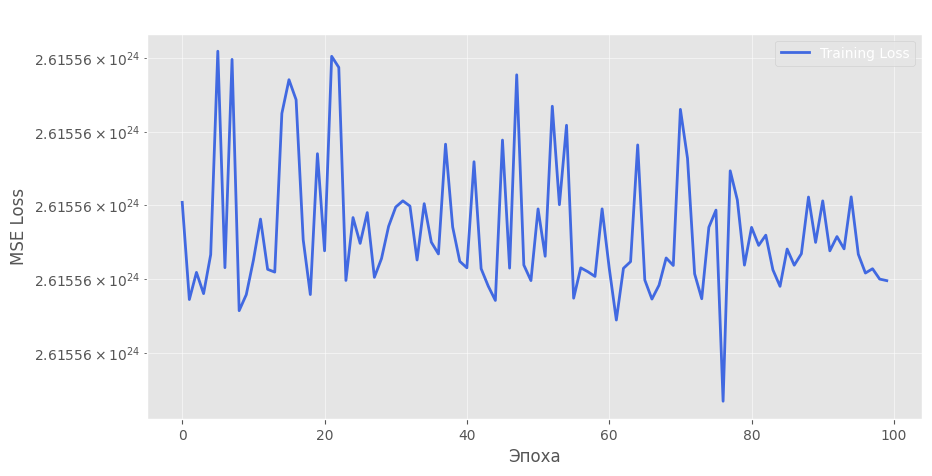

In [243]:
epochs = 100
batch_size = 32

loss_history = []


w_clf = 1.0  # Вес для классификации
w_reg = 0.005 # Вес для регрессии (цены)

criterion_mse = nn.MSELoss()
model.to(device)
for epoch in range(epochs):
    model.to(device)
    model.train()
    epoch_loss = 0

    indices = torch.randperm(X_train.size(0))

    for i in range(0, len(X_train), batch_size):
        batch_indices = indices[i : i + batch_size]
        batch_x = X_train[batch_indices].to(device)
        batch_y = Y_train[batch_indices].to(device)

        optimizer.zero_grad()

        pred_chances, pred_target = model(batch_x)

        true_target = batch_y[:, 0:1]   # Регрессия (x)
        true_chances = batch_y[:, 1:4]  # Классификация (1-n, n, 0.5)


        loss_reg = criterion_mse(pred_target, true_target)
        loss_clf = criterion_mse(pred_chances, true_chances)


        loss = (w_reg * loss_reg) + (w_clf * loss_clf)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / (len(X_train) / batch_size)
    loss_history.append(avg_loss)

    if (epoch + 1) % 1 == 0:
        print(f'Epoch [{epoch+1}/{epochs}] | Loss: {avg_loss:.6f} (Reg: {loss_reg:.4f}, Clf: {loss_clf:.4f})')

plt.figure(figsize=(10, 5))
plt.plot(loss_history, label='Training Loss', color='royalblue', linewidth=2)
plt.title('Процесс обучения нейросети (Loss Curve)')
plt.xlabel('Эпоха')
plt.ylabel('MSE Loss')
plt.yscale('log')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()
plt.show()

In [246]:
model.eval()
test_input = X_train[1].to(device)
with torch.no_grad():
    res_chances, res_target = model(test_input)

    res_chances = res_chances.cpu().numpy().tolist()
    res_target = res_target.item()
    print([res_chances,res_target])

[[0.33394381403923035, 0.4676893353462219, 0.40070241689682007], 3.7283377647399902]


In [245]:
device = torch.device('cpu')
model.to(device)
torch.save(model.state_dict(), 'stocker_ampepa.pth')